In [1]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
#
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [2]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_2.nc'

In [3]:
# 1. Helper function to extract ONLY flattened, valid seasonal points
def get_season_1d(ds, target_months):
    # Flatten arrays directly
    status = ds['status'].values.flatten()
    months = ds['time'].dt.month.values.flatten()
    
    # Create mask for valid water points AND the target season
    valid_mask = (status > 0) & (status < 4) & np.isin(months, target_months)
    
    # Return only data that passes the mask to save memory
    return {
        'lon': ds['lon'].values.flatten()[valid_mask],
        'lat': ds['lat'].values.flatten()[valid_mask],
        'z': ds['z'].values.flatten()[valid_mask],
        'status': status[valid_mask]
    }

# 2. Helper function to combine Year 1 and Year 2 mathematically
def build_combined_dataset(dict1, dict2):
    combined_dict = {}
    for var in ['lon', 'lat', 'z', 'status']:
        # Simulates 2-year release: (Year 1) + (Year 2) + (Year 1 again)
        combined_dict[var] = (['points'], np.concatenate([dict1[var], dict2[var], dict1[var]]))
    return xr.Dataset(combined_dict)

vars_to_keep = ['lon', 'lat', 'z', 'time', 'status']

with xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep]) as data1, \
     xr.open_dataset(filename2, drop_variables=[v for v in xr.open_dataset(filename2).variables if v not in vars_to_keep]) as data2:
    
    # Trim the overlapping restart point from Year 2 (obs=0)
    data2_trimmed = data2.isel(obs=slice(1, None))
    
    # 3. Extract points for each season directly from datasets
    print("Extracting Winter...")
    w1 = get_season_1d(data1, [1, 2, 3])
    w2 = get_season_1d(data2_trimmed, [1, 2, 3])
    
    print("Extracting Spring...")
    sp1 = get_season_1d(data1, [4, 5, 6])
    sp2 = get_season_1d(data2_trimmed, [4, 5, 6])
    
    print("Extracting Summer...")
    su1 = get_season_1d(data1, [7, 8, 9])
    su2 = get_season_1d(data2_trimmed, [7, 8, 9])
    
    print("Extracting Fall...")
    f1 = get_season_1d(data1, [10, 11, 12])
    f2 = get_season_1d(data2_trimmed, [10, 11, 12])
    
    # 4. Build the final 1D datasets
    print("Building final datasets...")
    data_winter = build_combined_dataset(w1, w2)
    data_spring = build_combined_dataset(sp1, sp2)
    data_summer = build_combined_dataset(su1, su2)
    data_fall   = build_combined_dataset(f1, f2)

print("Done! You can now run create_robust_swath().")

# Example usage with your function:
# swath_matrix_winter, z_bins = create_robust_swath(data_winter, thalweg, mask, d_km)

Extracting Winter...
Extracting Spring...
Extracting Summer...
Extracting Fall...
Building final datasets...
Done! You can now run create_robust_swath().


In [4]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [5]:
def particles_amount_map_by_depth(lons, lats, depths, depth_bins, mask=mask, num_lon=100, num_lat=100):
    # Create lon-lat bin edges
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)

    # Bin centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    results = {}
    raw_hist = {}
    grid_indices = {}  # to store ii_sed and jj_sed

    for depth_min, depth_max in depth_bins:
        # Select particles in current depth range
        depth_mask = (depths >= depth_min) & (depths <= depth_max)
        lon_sel = lons[depth_mask]
        lat_sel = lats[depth_mask]

        if len(lon_sel) > 0:
            counts, xedges, yedges = np.histogram2d(
                lon_sel, lat_sel,
                bins=[lon_edges, lat_edges]
            )
        else:
            counts = np.zeros((num_lon, num_lat))
            xedges, yedges = lon_edges, lat_edges

        # DataFrame (lat as rows, lon as cols)
        label = f"{depth_min}-{depth_max} m"
        results[label] = pd.DataFrame(
            counts.T,  # shape: (num_lat, num_lon)
            index=lat_centers,
            columns=lon_centers
        )

        # Raw hist outputs
        raw_hist[label] = (counts, xedges, yedges)

        # Build ii_sed and jj_sed on **bin centers**, same shape as counts.T
        Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)  # shape: (num_lat, num_lon)
        ii_sed = np.zeros_like(Xedges, dtype=int)
        jj_sed = np.zeros_like(Xedges, dtype=int)

        for i in range(Xedges.shape[0]):
            for j in range(Xedges.shape[1]):
                jj, ii = finder2(Yedges[i, j], Xedges[i, j], mask)
                ii_sed[i, j] = ii
                jj_sed[i, j] = jj

        grid_indices[label] = (ii_sed, jj_sed)

    return results, raw_hist, grid_indices


In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import cmocean # Assuming cm.dense comes from here

# --- 1. CONFIGURATION ---
depth_bins = [(0, 50), (50, 200), (200, 400)]
layers = ['0-50 m', '50-200 m', '200-400 m']

# Put your raw Xarray datasets into a dictionary
raw_datasets = {
    "WINTER": data_winter,
    "SPRING": data_spring,
    "SUMMER": data_summer,
    "FALL": data_fall
}

# Dictionaries to hold our processed results
water_amounts = {}
water_grids = {}

# --- 2. AUTOMATED PROCESSING LOOP ---
print("Processing spatial maps...")
for season, ds in raw_datasets.items():
    status_arr = ds['status'].values
    lon_arr = ds['lon'].values
    lat_arr = ds['lat'].values
    z_arr = ds['z'].values

    # Mask for water particles
    mask_wat = (status_arr > 0) & (status_arr < 4)
    
    # Process through your function
    amounts, _, grids = particles_amount_map_by_depth(
        lons=lon_arr[mask_wat], 
        lats=lat_arr[mask_wat], 
        depths=z_arr[mask_wat], 
        depth_bins=depth_bins,
        mask=mask # assuming 'mask' is loaded in your environment
    )
    
    water_amounts[season] = amounts
    water_grids[season] = grids

print("Data processing complete!")

Processing spatial maps...
Data processing complete!


In [7]:
def plot_seasonal_heatmaps(amounts_dict, grids_dict, mask, seasons_to_plot, layers_to_plot):
    plt.rcParams.update({'font.size': 20})
    
    # ====== 1. Compute Global Percentiles for Color Bounds ======
    all_vals = []
    for season in seasons_to_plot:
        for layer in layers_to_plot:
            arr = amounts_dict[season][layer].replace(0.0, np.nan).values.ravel()
            arr = arr[~np.isnan(arr)]
            if arr.size > 0:
                all_vals.append(arr)

    all_vals = np.concatenate(all_vals)
    PCTS = [10, 25, 50, 75, 90]
    global_Qs = np.nanpercentile(all_vals, PCTS)
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    
    bounds = [vmin, global_Qs[0], global_Qs[1], global_Qs[2], global_Qs[3], global_Qs[4], vmax]
    
    # ====== 2. Compute Layer Fractions per Season ======
    totals = {
        season: np.nansum([amounts_dict[season][layer] for layer in layers_to_plot])
        for season in seasons_to_plot
    }
    
    fractions = {
        season: {
            layer: 100 * np.nansum(amounts_dict[season][layer]) / totals[season]
            for layer in layers_to_plot
        }
        for season in seasons_to_plot
    }

    # ====== 3. Plot Setup ======
    rows = len(seasons_to_plot)
    cols = len(layers_to_plot)
    fig, axes = plt.subplots(rows, cols, figsize=(10, 6 * rows), constrained_layout=True)
    
    # Ensure axes is always a 2D array even if plotting 1 season
    if rows == 1: axes = np.expand_dims(axes, axis=0)
    
    cmap_3 = cmocean.cm.amp # Replace with your specific colormap if different
    norm = BoundaryNorm(bounds, cmap_3.N)
    
    # Prepare land mask background coordinates (assuming X, Y are 2D meshgrids of your model domain)
    X, Y = np.meshgrid(np.arange(mask['tmask'].shape[3]), np.arange(mask['tmask'].shape[2]))

    # ====== 4. Plotting Loop ======
    for r, season in enumerate(seasons_to_plot):
        for c, layer in enumerate(layers_to_plot):
            ax = axes[r, c]
            data = amounts_dict[season][layer]
            
            # The grids dictionary structure: grids[season][layer][0] is ii_sed, [1] is jj_sed
            grid_x = grids_dict[season][layer][0]
            grid_y = grids_dict[season][layer][1]

            # Heatmap
            cf = ax.contourf(
                grid_x, grid_y, data,
                levels=bounds, cmap=cmap_3, norm=norm, extend="both"
            )

            # Land mask overlay
            ax.pcolormesh(X, Y, mask['tmask'][0][0], cmap='gray_r', alpha=0.3)

            # Labels and Aesthetics
            if r == 0:
                # Give nice titles based on layer
                title_map = {"0-50 m": "Surface (0–50 m)", "50-200 m": "Intermediate (50–200 m)", "200-400 m": "Bottom (200–400 m)"}
                ax.set_title(title_map.get(layer, layer), fontsize=14)
            if c == 0:
                ax.set_ylabel(season, fontsize=30)
                
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect(1.14)

            # ====== 5. Annotations ======
            perc = fractions[season][layer]
            
            # Title above box
            ax.text(
                0.5, 0.01, '% from Total: ' + f"{perc:.1f}%", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=14, color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8)
            )
            # Value box
            #ax.text(
            #    0.81, 0.01, f"{perc:.1f}%", transform=ax.transAxes,
            #    ha="center", va="bottom", fontsize=16,
            #    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            #)

    # ====== 6. Global Colorbar ======
    cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.05, pad=0.02)
    cbar.set_ticks(global_Qs)
    cbar.set_ticklabels(["Q10", "Q25", "Q50", "Q75", "Q90"])
    cbar.set_label('Percentiles from Total in the Water Column')
    plt.show()
    plt.tight_layout()

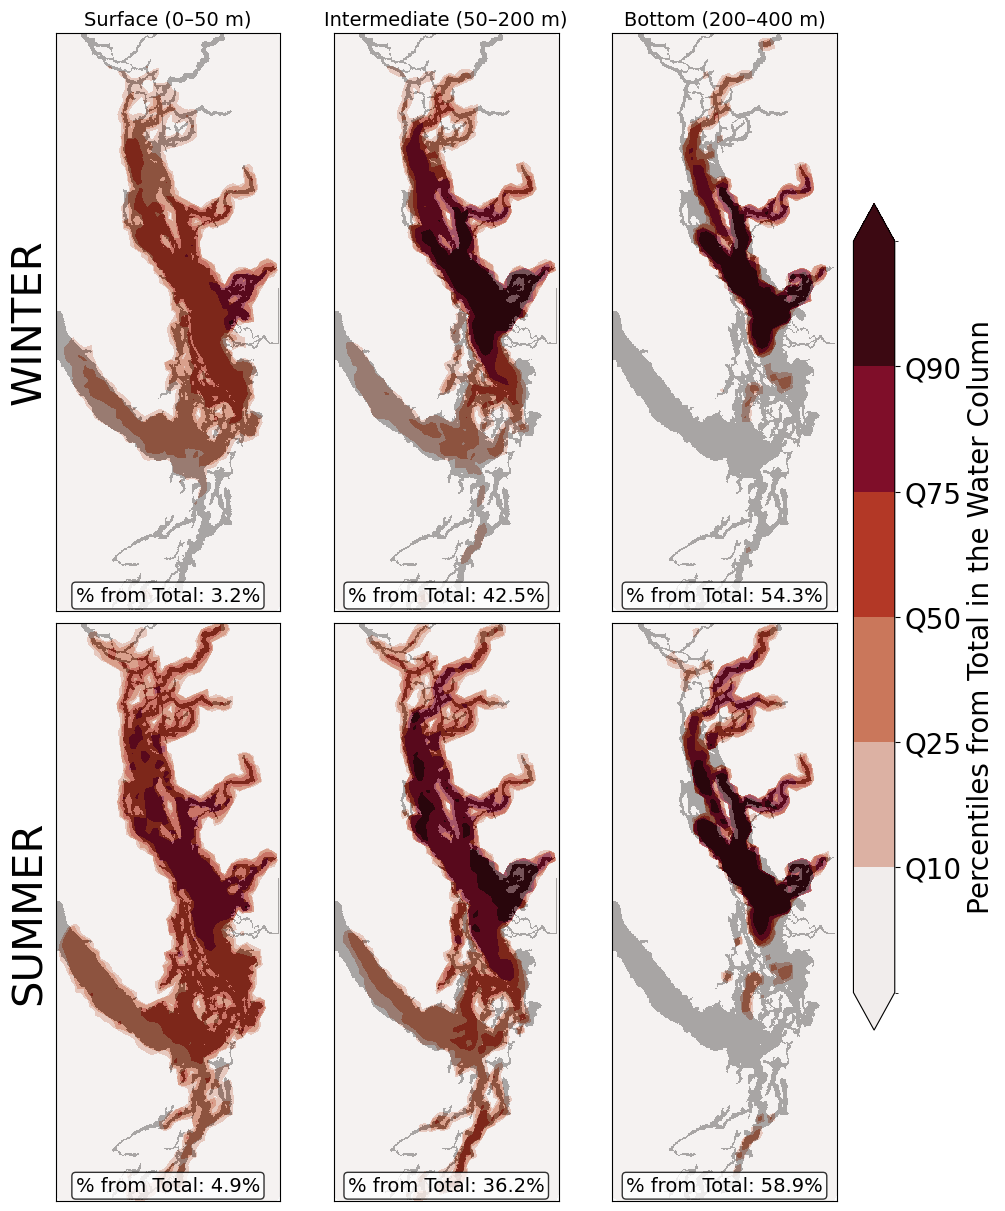

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
seasons_to_plot = ["WINTER", "SUMMER"]
plot_seasonal_heatmaps(water_amounts, water_grids, mask, seasons_to_plot, layers)